# Bank Customer Term Deposit Prediction

This notebook trains a TensorFlow binary classification model to predict whether a bank customer will subscribe to a term deposit.

## Main improvements in this rewritten version

- Uses the real `bank(1).csv` dataset structure.
- Avoids data leakage by fitting preprocessing only on the training set.
- Uses `OneHotEncoder` for all categorical columns.
- Uses `StandardScaler` for numerical columns.
- Uses a clean TensorFlow model with `Dense(1, activation="sigmoid")`.
- Uses `binary_crossentropy`, which matches binary classification.
- Uses `EarlyStopping` to reduce overfitting.
- Saves both:
  - `bank_model.keras`
  - `preprocessor.joblib`

These two files are needed for Streamlit deployment.

In [1]:
# =========================
# 1. Imports
# =========================

from pathlib import Path
import json
import random
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

I0000 00:00:1781782171.612719   31635 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781782171.613093   31635 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781782171.647468   31635 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781782172.484025   31635 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
# =========================
# 2. Project Configuration
# =========================

DATA_PATH = Path("bank(1).csv")

# Fallback path if your old dataset folder is used
if not DATA_PATH.exists():
    DATA_PATH = Path("../dataset/bank.csv")

MODEL_DIR = Path("model")
MODEL_DIR.mkdir(exist_ok=True)

MODEL_PATH = MODEL_DIR / "bank_model.keras"
PREPROCESSOR_PATH = MODEL_DIR / "preprocessor.joblib"
METRICS_PATH = MODEL_DIR / "metrics.json"

TARGET_COLUMN = "deposit"

# For mini project / assignment, keeping duration is okay.
# For real business prediction before calling the customer, set this to False.
USE_DURATION = True

In [3]:
# =========================
# 3. Load Dataset
# =========================

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}. "
        "Please place bank(1).csv in the same folder as this notebook."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
# =========================
# 4. Basic Dataset Check
# =========================

print("Columns:")
print(df.columns.tolist())

print("\nDataset info:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicated rows:")
print(df.duplicated().sum())

Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-nul

In [5]:
# =========================
# 5. Target Distribution
# =========================

target_counts = df[TARGET_COLUMN].value_counts()
target_percentages = df[TARGET_COLUMN].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages.round(2)
})

target_summary

,count,percentage
deposit,,
no,5873,52.62
yes,5289,47.38


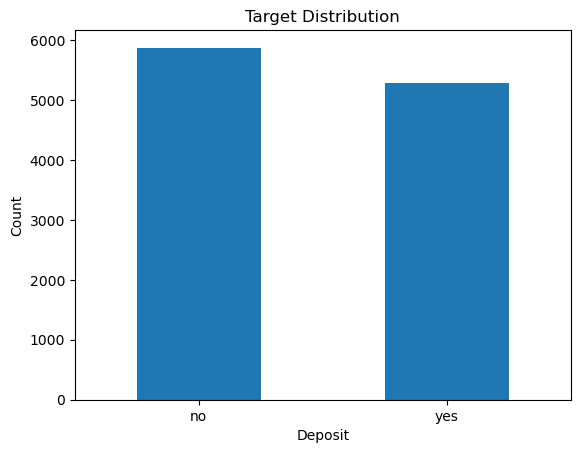

In [6]:
# Target distribution plot

target_counts.plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Deposit")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## Column Selection

The dataset contains categorical and numerical features.

`duration` is included by default because this is a mini project.  
However, for real prediction before a phone call, `duration` should be removed because it is only known after the call finishes.

In [7]:
# =========================
# 6. Define Columns
# =========================

categorical_columns = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome",
]

numerical_columns = [
    "age",
    "balance",
    "day",
    "campaign",
    "pdays",
    "previous",
]

if USE_DURATION:
    numerical_columns.append("duration")

feature_columns = categorical_columns + numerical_columns

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

print("\nTarget column:")
print(TARGET_COLUMN)

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Numerical columns:
['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'duration']

Target column:
deposit


In [8]:
# =========================
# 7. Check Unique Values
# =========================

for col in categorical_columns:
    print(f"{col}:")
    print(sorted(df[col].unique()))
    print("-" * 50)

job:
['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown']
--------------------------------------------------
marital:
['divorced', 'married', 'single']
--------------------------------------------------
education:
['primary', 'secondary', 'tertiary', 'unknown']
--------------------------------------------------
default:
['no', 'yes']
--------------------------------------------------
housing:
['no', 'yes']
--------------------------------------------------
loan:
['no', 'yes']
--------------------------------------------------
contact:
['cellular', 'telephone', 'unknown']
--------------------------------------------------
month:
['apr', 'aug', 'dec', 'feb', 'jan', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep']
--------------------------------------------------
poutcome:
['failure', 'other', 'success', 'unknown']
--------------------------------------------------


In [9]:
# =========================
# 8. Numerical Summary
# =========================

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,11162.0,41.231948,11.913369,18.0,32.0,39.0,49.00,95.0
balance,11162.0,1528.538524,3225.413326,-6847.0,122.0,550.0,1708.00,81204.0
day,11162.0,15.658036,8.420740,1.0,8.0,15.0,22.00,31.0
campaign,11162.0,2.508421,2.722077,1.0,1.0,2.0,3.00,63.0
pdays,11162.0,51.330407,108.758282,-1.0,-1.0,-1.0,20.75,854.0
previous,11162.0,0.832557,2.292007,0.0,0.0,0.0,1.00,58.0
duration,11162.0,371.993818,347.128386,2.0,138.0,255.0,496.00,3881.0


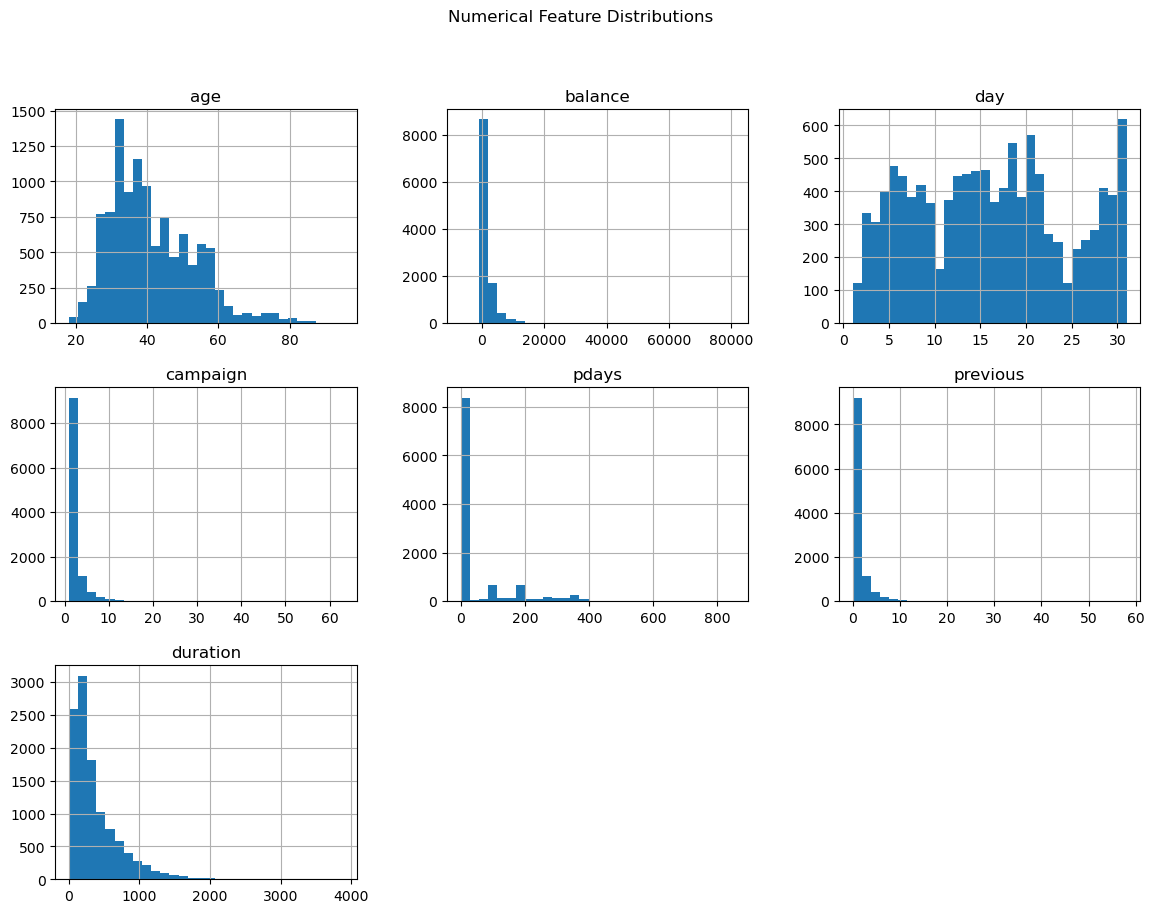

In [10]:
# Numerical features distribution

df[numerical_columns].hist(figsize=(14, 10), bins=30)
plt.suptitle("Numerical Feature Distributions")
plt.show()

## Prepare Features and Target

The target `deposit` is converted from:

- `yes` → `1`
- `no` → `0`

In [11]:
# =========================
# 9. Prepare X and y
# =========================

df_model = df.copy()

df_model[TARGET_COLUMN] = df_model[TARGET_COLUMN].map({
    "yes": 1,
    "no": 0,
})

X = df_model[feature_columns]
y = df_model[TARGET_COLUMN].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

y.value_counts()

X shape: (11162, 16)
y shape: (11162,)


deposit
0    5873
1    5289
Name: count, dtype: int64

In [12]:
# =========================
# 10. Train / Test Split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8929, 16)
X_test: (2233, 16)
y_train: (8929,)
y_test: (2233,)


## Preprocessing

Important rule:

The preprocessor must be fitted only on the training data.

Correct:

```python
preprocessor.fit(X_train)
```

Wrong:

```python
preprocessor.fit(X)
```

Fitting on the full dataset causes data leakage.

In [13]:
# =========================
# 11. Build Preprocessing Pipeline
# =========================

# Compatibility for different scikit-learn versions
try:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", one_hot_encoder, categorical_columns),
    ],
    remainder="drop",
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor)
    ]
)

# Fit only on training data
pipeline.fit(X_train)

X_train_tf = pipeline.transform(X_train)
X_test_tf = pipeline.transform(X_test)

print("Processed X_train shape:", X_train_tf.shape)
print("Processed X_test shape:", X_test_tf.shape)

Processed X_train shape: (8929, 51)
Processed X_test shape: (2233, 51)


In [14]:
# =========================
# 12. Get Processed Feature Names
# =========================

processed_feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

feature_names_path = MODEL_DIR / "feature_names.json"

with open(feature_names_path, "w", encoding="utf-8") as file:
    json.dump(processed_feature_names.tolist(), file, indent=2)

print("Number of processed features:", len(processed_feature_names))
print("Saved feature names to:", feature_names_path)

Number of processed features: 51
Saved feature names to: model/feature_names.json


## TensorFlow Model

This is a binary classification problem, so the model uses:

```python
Dense(1, activation="sigmoid")
```

and:

```python
loss="binary_crossentropy"
```

In [15]:
# =========================
# 13. Build TensorFlow Model
# =========================

input_shape = X_train_tf.shape[1]

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_shape,)),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

E0000 00:00:1781782290.393174   31635 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,441 (21.25 KB)

 Trainable params: 5,441 (21.25 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# =========================
# 14. Train Model
# =========================

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_tf,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7409 - loss: 0.5279 - val_accuracy: 0.8219 - val_loss: 0.4164
Epoch 2/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8153 - loss: 0.4152 - val_accuracy: 0.8348 - val_loss: 0.3966
Epoch 3/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8285 - loss: 0.3913 - val_accuracy: 0.8443 - val_loss: 0.3873
Epoch 4/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8342 - loss: 0.3819 - val_accuracy: 0.8455 - val_loss: 0.3839
Epoch 5/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8391 - loss: 0.3717 - val_accuracy: 0.8488 - val_loss: 0.3772
Epoch 6/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8457 - loss: 0.3627 - val_accuracy: 0.8494 - val_loss: 0.3739
Epoch 7/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8464 - loss: 0.3573 - val_accuracy: 0.8544 - val_loss: 0.3701
Epoch 8/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8508 - loss: 0.3543 - val_accu

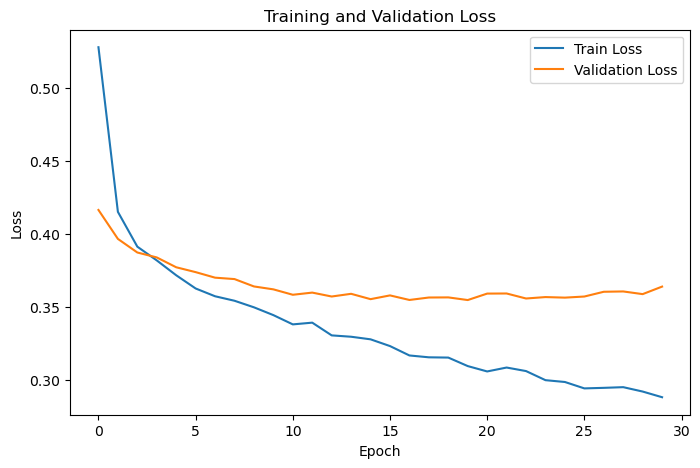

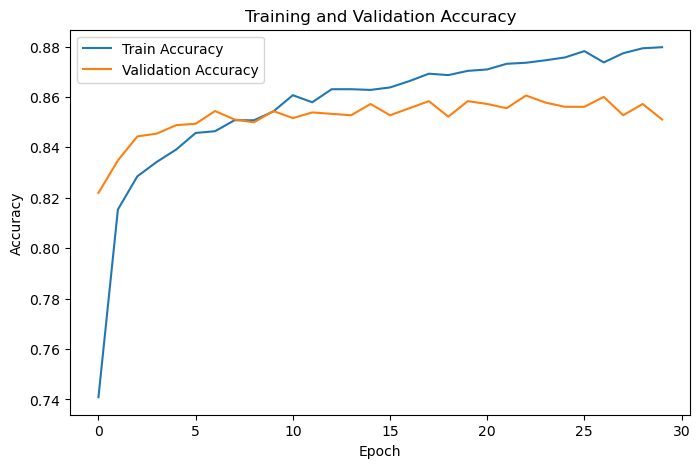

In [17]:
# =========================
# 15. Plot Training History
# =========================

history_df = pd.DataFrame(history.history)

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["accuracy"], label="Train Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Model Evaluation

The test set is used here only after training.

In [18]:
# =========================
# 16. Evaluate Model
# =========================

y_pred_prob = model.predict(X_test_tf).reshape(-1)
y_pred = (y_pred_prob >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print("Test Accuracy:", round(accuracy, 4))
print("ROC AUC:", round(roc_auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["no", "yes"]))

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 982us/step
Test Accuracy: 0.8607
ROC AUC: 0.9213

Classification Report:
              precision    recall  f1-score   support

          no       0.90      0.83      0.86      1175
         yes       0.83      0.90      0.86      1058

    accuracy                           0.86      2233
   macro avg       0.86      0.86      0.86      2233
weighted avg       0.86      0.86      0.86      2233



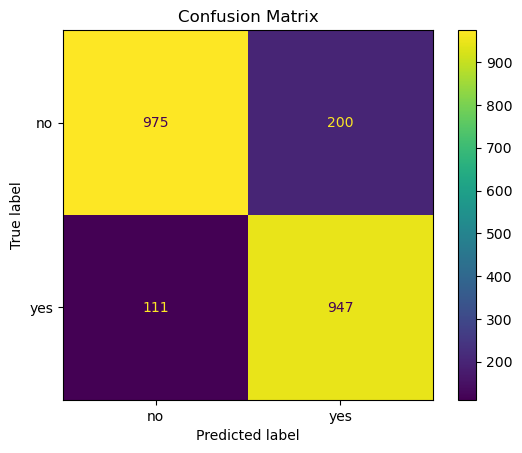

In [19]:
# =========================
# 17. Confusion Matrix
# =========================

cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["no", "yes"]
)

display.plot()
plt.title("Confusion Matrix")
plt.show()

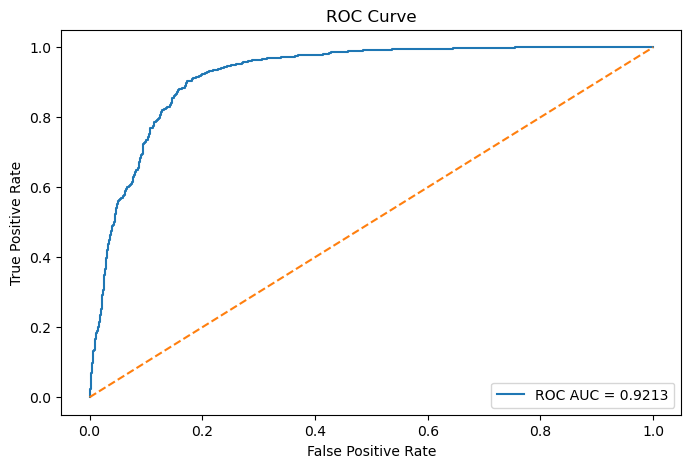

In [20]:
# =========================
# 18. ROC Curve
# =========================

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [21]:
# =========================
# 19. Save Model, Preprocessor, and Metrics
# =========================

joblib.dump(pipeline, PREPROCESSOR_PATH)
model.save(MODEL_PATH)

metrics = {
    "accuracy": float(accuracy),
    "roc_auc": float(roc_auc),
    "use_duration": USE_DURATION,
    "categorical_columns": categorical_columns,
    "numerical_columns": numerical_columns,
    "feature_columns": feature_columns,
    "model_path": str(MODEL_PATH),
    "preprocessor_path": str(PREPROCESSOR_PATH),
}

with open(METRICS_PATH, "w", encoding="utf-8") as file:
    json.dump(metrics, file, indent=2)

print("Saved model to:", MODEL_PATH)
print("Saved preprocessor to:", PREPROCESSOR_PATH)
print("Saved metrics to:", METRICS_PATH)

Saved model to: model/bank_model.keras
Saved preprocessor to: model/preprocessor.joblib
Saved metrics to: model/metrics.json


## Single Prediction Test

This section tests prediction using one row from the test set.
It also shows the same prediction style you will use inside Streamlit.

In [23]:
# =========================
# 20. Test Single Prediction
# =========================

from IPython.display import display as ipy_display

sample = X_test.iloc[[0]]
actual = y_test.iloc[0]

sample_processed = pipeline.transform(sample)
sample_probability = float(model.predict(sample_processed)[0][0])
sample_prediction = 1 if sample_probability >= 0.5 else 0

print("Sample input:")
ipy_display(sample)

print("Actual:", actual)
print("Predicted:", sample_prediction)
print("Probability:", round(sample_probability, 4))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Sample input:


,job,marital,education,default,housing,loan,contact,month,poutcome,age,balance,day,campaign,pdays,previous,duration
8220,management,married,tertiary,no,no,no,cellular,jan,unknown,32,393,28,2,-1,0,458


Actual: 0
Predicted: 0
Probability: 0.4766


In [24]:
# =========================
# 21. Deployment Function Example
# =========================

def predict_deposit(input_data: dict):
    """
    input_data example:
    {
        "age": 35,
        "job": "management",
        "marital": "married",
        "education": "tertiary",
        "default": "no",
        "balance": 1000,
        "housing": "yes",
        "loan": "no",
        "contact": "cellular",
        "day": 15,
        "month": "may",
        "duration": 180,
        "campaign": 1,
        "pdays": -1,
        "previous": 0,
        "poutcome": "unknown"
    }
    """

    loaded_model = tf.keras.models.load_model(MODEL_PATH)
    loaded_pipeline = joblib.load(PREPROCESSOR_PATH)

    input_df = pd.DataFrame([input_data])
    input_df = input_df[feature_columns]

    processed_input = loaded_pipeline.transform(input_df)
    probability = float(loaded_model.predict(processed_input, verbose=0)[0][0])

    prediction = "yes" if probability >= 0.5 else "no"

    return {
        "prediction": prediction,
        "probability": probability,
    }


example_input = {
    "age": 35,
    "job": "management",
    "marital": "married",
    "education": "tertiary",
    "default": "no",
    "balance": 1000,
    "housing": "yes",
    "loan": "no",
    "contact": "cellular",
    "day": 15,
    "month": "may",
    "campaign": 1,
    "pdays": -1,
    "previous": 0,
    "poutcome": "unknown",
}

if USE_DURATION:
    example_input["duration"] = 180

predict_deposit(example_input)

{'prediction': 'no', 'probability': 0.12566137313842773}

# Final Notes

For Streamlit deployment, copy these files into your Streamlit project:

```txt
model/bank_model.keras
model/preprocessor.joblib
model/metrics.json
```

Your Streamlit app should load both the TensorFlow model and the preprocessor.  
Do not manually encode the Streamlit input differently from this notebook.